## **Tutorial: Generating an Airy Sea Profile with WaveSpec.jl**

This tutorial demonstrates how to use the WaveSpec package to simulate a primary sea state using Airy Wave Theory. We will construct a synthetic sea surface by defining two independent distributions modeling the sea spectral density and the angular spreading. 
Both distributions are discretized it into components, and added in order to generate the sea profiles according to Airy Wave theory.

If we look out to sea, we notice that waves on the sea surface are not simple sinusoids. 
The surface appears to be composed of random waves of various lengths and periods. 
How can we describe this surface? The simple answer is, not very easily. 
We can however, with some simplifications, come close to describing the surface. 
The simplifications lead to the concept of the spectrum of ocean waves. 
The spectrum gives the distribution of wave energy among different wave frequencies of wave-lengths on the sea surface.

In Airy Wave Theory (Linear Wave Theory), a stochastic sea state is modeled as the superposition of an infinite number of independent harmonic wave components. 
To describe a realistic ocean surface, we must account for both:
- **Frequency Spectrum $S(f)$:** This defines the energy density distributed across different frequencies. Common models include JONSWAP or Pierson-Moskowitz. 
- **Angular Spreading $D(\theta)$:** This defines the energy density distributed across different angles. It is normalized such that the total density is 1. 

From each continuous distribution $S(f)$ and $D(\theta)$ can be sampled discrete frequencies $f_i$ and angles $\theta_j$ respectively, such that the amplitude $A_{ij}$ for a specific frequency-direction component is calculated from the energy contained within that bin:
$$ A_{ij} = \sqrt{2 \cdot S(f_i) \cdot D(\theta_j) \cdot \Delta f \cdot \Delta \theta} $$
By summing these components, the sea surface transforms from "long-crested" (waves moving in a single direction) to "short-crested" (realistic chaotic ocean surface).
​
With these amplitudes and the wave numbers and angular frequencies derived from the dispersion relation, we can generate the sea surface elevation $\eta(x,y,t)$ at any point in space and time using:
$$ \eta(x,y,t) = \sum_{i=1}^{N_f} \sum_{j=1}^{N_\theta} A_{ij}  \cos(k_i x  \cos{\theta_j} + k_i y  \sin{\theta_j} - \omega_i t + \phi_{ij}) $$
where $\phi_{ij}$ are random phase shifts uniformly distributed in $[0, 2\pi)$. The wave number $k_i$ and angular frequency $\omega_i$ are calculated using the linear dispersion relation for deep water waves:
$$ \omega_i^2 = g k  \tanh(k h) $$

Package `WaveSpec` has been built following this concept of independent distributions and (frequency, angle) components to generate realistic sea states. Below, we will walk through the steps to create an Airy sea profile using `WaveSpec`.  

Let's start by importing the necessary packages.

In [1]:
using WaveSpec
using Distributions
using Plots

Precompiling packages...
   1714.5 ms  ✓ WaveSpec
  1 dependency successfully precompiled in 4 seconds. 209 already precompiled.
[ Info: WaveSpec initialized: Ready for spectral sea state synthesis.


#### **Generate Discrete Angular Spreading model**

In a first instance, we define a distribution to model the Airy waves' angular spreading. Such an entity can be generated using the structure `DiscreteAngularSpreading` which is constituted by a fundamental `UnivariateContinuousDistribution` (see package Distributions), truncated using the distribution truncation tool `TruncatedModel` in module `Truncation` and discretised according to the number of samples $n\theta$ specified by the used.

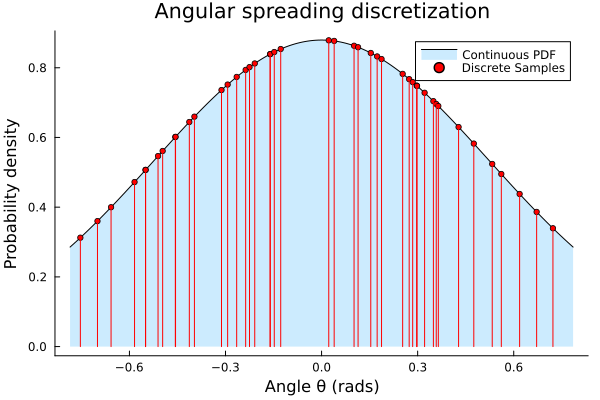

In [2]:
# Generate angular spreading structure
using WaveSpec.AngularSpreading

μ = 0.0         # Mean direction
σ = π/6         # Standard deviation
θmin = - π/4    # Minimum angle
θmax = π/4      # Maximum angle
nθ = 45         # Number of discrete angles (number of bins = nθ - 1)

AngSprea = DiscreteAngularSpreading(:normal, μ, σ, θmin, θmax, nθ) 

plot(AngSprea)

#### **Generate Continuous Spectral model**

We move now towards the wave spectral model, with describes how the energy of the sea waves is distributed across the frequency domain.
We select for instance the well known JONSWAP spectrum 

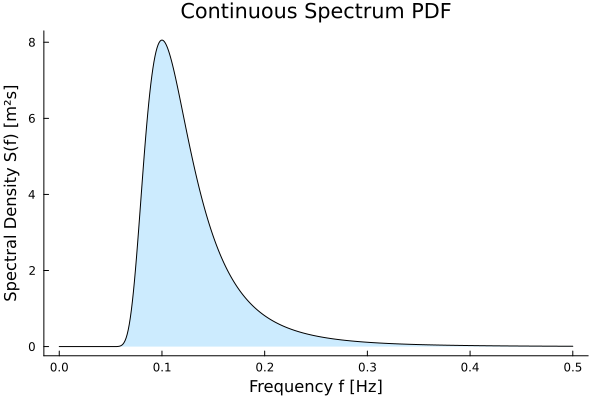

In [3]:
using WaveSpec.ContinuousSpectrums

# Generate continuous spectrum model 
Hs = 3.0    # Significant Wave Height (m)
Tp = 10.0   # Peak Period (s)
Cspec = JONSWAP(Hs, Tp)

plot(Cspec)

#### **Generate Discrete Spectral model**

The Continuous spectrum must be now discretised into frequency samples, generating a new structure `DiscreteSpectralSpreading`. 
The discretisation is characterised by two distinct features:
- the **sampling domain**: this selects respect to which domain, either `FrequencyDomain` or `EnergyDomain`, the sampling strategy (method) will be carried out.
- the **sampling stategy**: this selects how the frequencies are taken on the choosen domain.

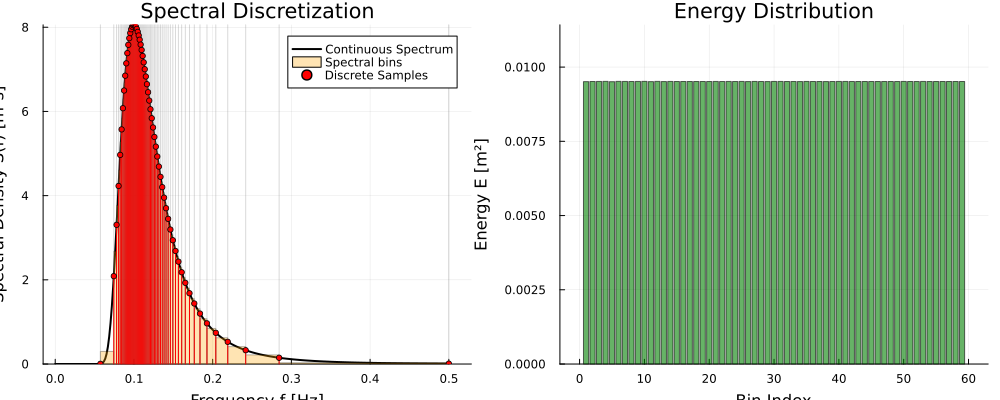

In [ ]:
using WaveSpec.SpectralSampling
using WaveSpec.SpectralSpreading

# Generate discrete spectrum 
nf = 60
Dspec = DiscreteSpectralSpreading(Cspec, UniformSampling(), get_fmin(Cspec), get_fmax(Cspec), nf;
    domain=SpectralSampling.Energy, mess=false)

plot(Dspec)

In [5]:
using WaveSpec.AiryWaves

# Generate Airy sea state
h = 30.0     # Water depth (m)
airysea = AiryState(Dspec, AngSprea, h)

AiryState(DiscreteSpectralSpreading(JONSWAP{Float64}(3.0, 10.0, 0.1, 1.0, 1.0000078065322076, 0.6283185307179586, 0.07, 0.09), UniformSampling(), EnergyDomain(), 1.0e-5, 0.5, 60, 59, 1.0164844001817674), DiscreteAngularSpreading{Normal{Float64}, Float64}(WaveSpec.Truncation.TruncatedModel{Normal{Float64}, Float64}(
dist: Normal{Float64}(μ=0.0, σ=0.5235987755982988)
a: -0.7853981633974483
b: 0.7853981633974483
Z: 0.8663855974622838
cdf_a: 0.06680720126885804
cdf_b: 0.9331927987311419
)
, 45, 2488212062649337799), 59, 44, [0.41402337530439914, 0.4786092295995262, 0.49768227810866855, 0.5121146183170031, 0.5242769923568005, 0.5350706678082363, 0.5449525867459093, 0.5541806335060269, 0.5629277049364667, 0.5713140771634447  …  1.0239016545408772, 1.0550658348535573, 1.0908711451745614, 1.1328446667713115, 1.1833549980164522, 1.2463773515573051, 1.3293294246717542, 1.4485638941783743, 1.653676915208601, 2.4644147478965786], [0.026461065735819345, 0.031608399751975366, 0.033223820507523406, 0

In [6]:
# Define spatial grid: 100m x 100m
nx, ny = 100, 100
x_coords = range(-50.0, 50.0, length=nx)
y_coords = range(-50.0, 50.0, length=ny)

# Time and vertical position (surface)
t_val = [0.0]
z_val = [0.0]

profiles = generate_sea(airysea, x_coords, y_coords, z_val, t_val, vars=[:η])

(η = [-0.5034770128833873 -0.5260279990249151 … 0.03837601878467598 0.014987734284333087; -0.4864288456891908 -0.48962367430447234 … 0.08513656905047265 0.05627363952145264; … ; -0.2866171213887667 -0.28473652322956255 … 0.33031999453990063 0.35892211701957855; -0.3229452287589426 -0.3170932571894937 … 0.35246464636801844 0.3839908909102538;;;;],)

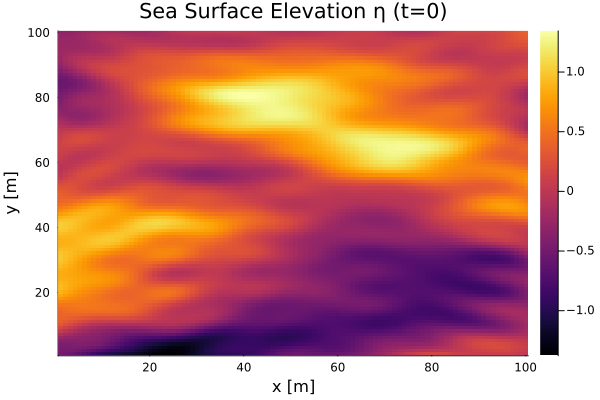

In [7]:
# Plotting
p1 = heatmap(profiles.η[:,:,1,1], 
             colorbar=true, 
             title="Sea Surface Elevation η (t=0)",
             xlabel="x [m]", ylabel="y [m]")